In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import hypernetx as hnx

In [2]:

with open('../database/edges.csv', mode='r') as file:
    edges = pd.read_csv(file)

with open('../database/stations.csv', mode='r') as file:
    stations = pd.read_csv(file)

with open("../database/routes.tsv", newline='') as file:
    reader = csv.reader(file, delimiter='\t')
    routes = [row for row in reader]

In [3]:
clean_routes = []
for row in routes:
    if row not in clean_routes:
        clean_routes.append(row)
print(clean_routes[:5])

[['SVG', 'WAS', 'HFN', 'BAY', 'CUF', 'CWH', 'GDH', 'ENC', 'GPK', 'WIH', 'PAL', 'BOP', 'AAP', 'HRN', 'HGY', 'FPK', 'KGX'], ['KGX', 'FPK', 'HGY', 'HRN', 'AAP', 'BOP', 'PAL', 'WIH', 'GPK', 'ENC', 'GDH', 'CWH', 'CUF', 'BAY', 'HFN', 'WAS', 'SVG'], ['KGX', 'FPK', 'HGY', 'HRN', 'AAP', 'NSG', 'OKL', 'NBA', 'HDW', 'PBR', 'BPK', 'WMG', 'HAT', 'WGC'], ['WGC', 'HAT', 'WMG', 'BPK', 'PBR', 'HDW', 'NBA', 'OKL', 'NSG', 'AAP', 'HRN', 'HGY', 'FPK', 'KGX'], ['PPD', 'ACY', 'PER', 'MTA', 'FER', 'CMH', 'ABA']]


In [4]:
edges.describe(include="object")

,source,target
count,7636,7636
unique,2556,2556
top,LDS,BHM
freq,24,24


In [5]:
edges.describe()

,distance
count,7636.000000
mean,10.464650
std,21.717175
min,0.000000
25%,2.280000
50%,4.750000
75%,10.432500
max,531.380000


In [6]:
edges.sort_values("distance")

,source,target,distance
4253,LST,LST,0.00
4832,NLR,LWR,0.04
4320,LWR,NLR,0.04
525,BFR,CTK,0.24
1727,CTK,BFR,0.24
...,...,...,...
4778,NCL,SVG,353.64
5322,PRE,KIN,378.98
4773,NCL,KGX,395.03
3702,KGX,NCL,395.03


# Degree analysis

<Figure size 800x400 with 0 Axes>

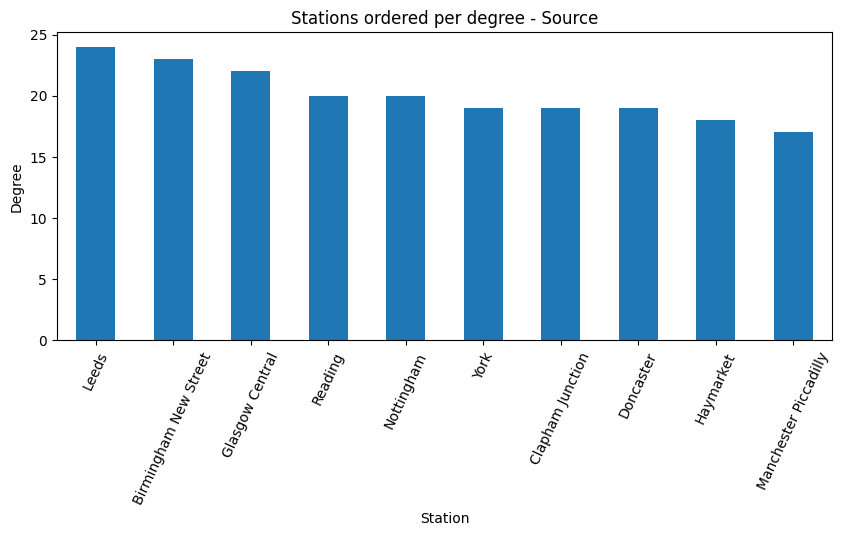

In [7]:
import matplotlib.pyplot as plt

degree = edges['source'].value_counts()

df_degree = stations.merge(degree.to_frame(), left_on="code", right_index=True)
df_degree = df_degree.sort_values("count", ascending=False)

# Top 10
top_10 = df_degree.head(10)
plt.figure(figsize=(8,4))
top_10.plot(kind='bar', x='name', y='count', legend=False,figsize=(10,4))
plt.title("Stations ordered per degree - Source")
plt.xlabel("Station")
plt.ylabel("Degree", loc='center')
plt.xticks(rotation=65, fontsize=10)
plt.show()


<Figure size 1000x400 with 0 Axes>

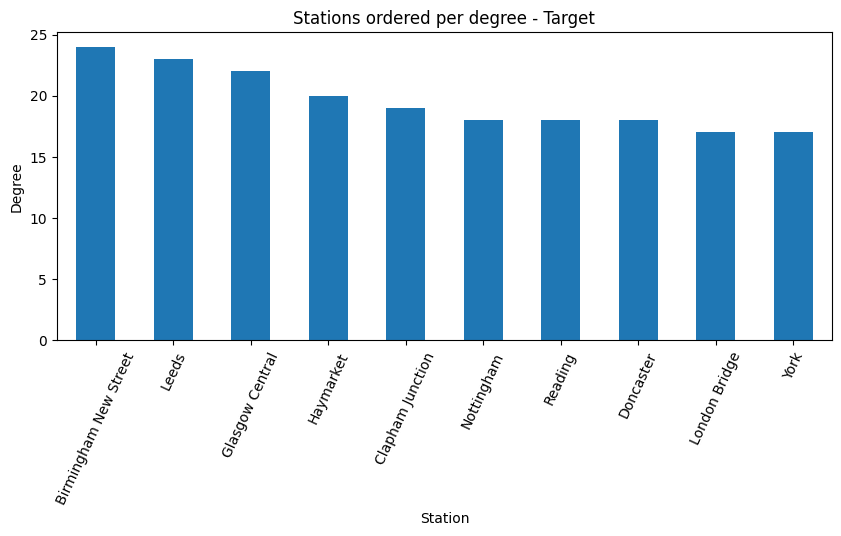

In [8]:
import matplotlib.pyplot as plt

degree = edges['target'].value_counts()

df_degree = stations.merge(degree.to_frame(), left_on="code", right_index=True)
df_degree = df_degree.sort_values("count", ascending=False)

# Top 10
top_10 = df_degree.head(10)
plt.figure(figsize=(10,4))
top_10.plot(kind='bar', x='name', y='count', legend=False,figsize=(10,4))
plt.title("Stations ordered per degree - Target")
plt.xlabel("Station")
plt.ylabel("Degree", loc='center')
plt.xticks(rotation=65, fontsize=10)
plt.show()


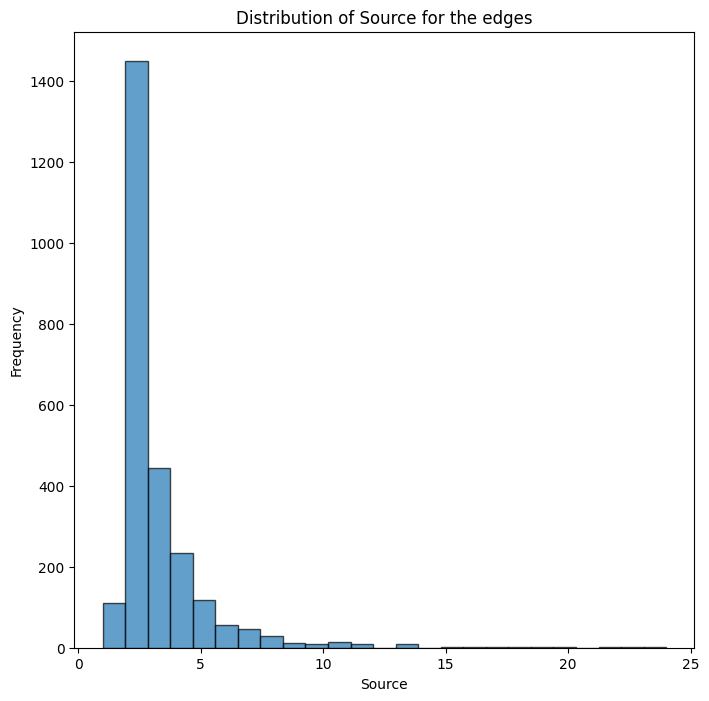

In [9]:
edges['source'].value_counts().plot(kind='hist', bins=25, edgecolor='black', alpha=0.7)
plt.title('Distribution of Source for the edges')
plt.xlabel('Source')
plt.ylabel('Frequency')
plt.show()


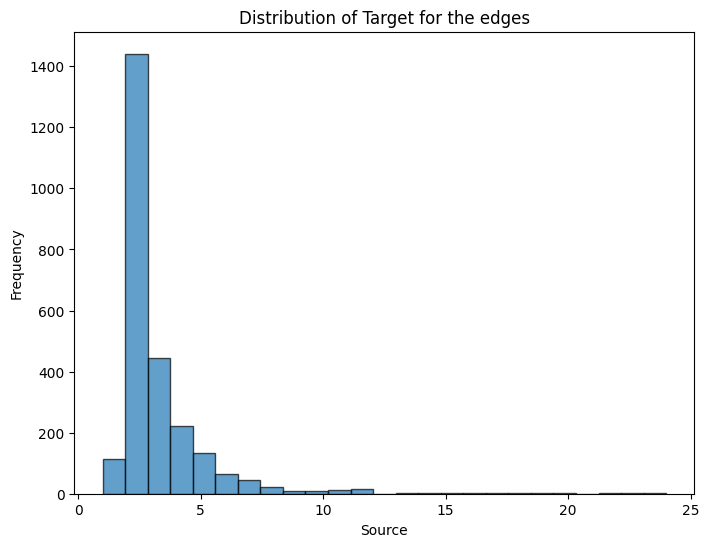

In [10]:
edges['target'].value_counts().plot(kind='hist', bins=25, edgecolor='black', alpha=0.7, figsize=(8,6))
plt.title('Distribution of Target for the edges')
plt.xlabel('Source')
plt.ylabel('Frequency')
plt.show()


In [11]:
edges = edges.merge(stations, left_on="source", right_on="code", how="left" )
edges = edges.merge(stations, left_on="target", right_on="code", how="left", suffixes=("_source", "_target"))

edges = edges.drop(columns=['code_source', 'code_target'])

## Analysis of the routes

In [12]:
from collections import Counter

# Suppose routes is a list of lists like:
# [['SVG', 'WAS', 'HFN'], ['HFN', 'BAY'], ['SVG', 'BAY']]

# Flatten it
flat = [station for route in routes for station in route]

# Count frequencies
freq = Counter(flat)

# Show top 10 most common stations
print(freq.most_common(10))


[('CLJ', 4404), ('LST', 3285), ('LBG', 3007), ('ZLW', 2972), ('ZFD', 2908), ('SRA', 2781), ('WAT', 2671), ('PAD', 2356), ('HHY', 2343), ('GLC', 2179)]


In [13]:
freq_df = pd.DataFrame(freq.items(), columns=['station', 'count'])
freq_df = freq_df.sort_values('count', ascending=False)
freq_df.reset_index()
print(freq_df.head())


    station  count
309     CLJ   4404
123     LST   3285
472     LBG   3007
124     ZLW   2972
122     ZFD   2908


In [14]:
freq_df.describe()

,count
count,2577.000000
mean,228.831199
std,314.519520
min,1.000000
25%,63.000000
50%,134.000000
75%,262.000000
max,4404.000000


In [15]:
freq_df = freq_df.merge(stations, left_on="station", right_on="code", how="left" )
freq_df.head()

,station,count,code,lat,long,name
0,CLJ,4404,CLJ,51.464191,-0.170247,Clapham Junction
1,LST,3285,LST,51.518023,-0.081996,London Liverpool Street
2,LBG,3007,LBG,51.505096,-0.085060,London Bridge
3,ZLW,2972,ZLW,51.519467,-0.059757,Whitechapel
4,ZFD,2908,ZFD,51.520530,-0.105040,Farringdon


In [16]:
freq_df.describe()

,count,lat,long
count,2578.000000,2557.000000,2557.000000
mean,228.960822,52.808036,-1.769496
std,314.527356,1.747856,1.696835
min,1.000000,50.121682,-5.839071
25%,63.250000,51.463102,-3.088443
50%,134.000000,52.344369,-1.704018
75%,262.000000,53.652553,-0.220834
max,4404.000000,58.589987,1.749728


## Hyperdegree analysis

<Figure size 1000x500 with 0 Axes>

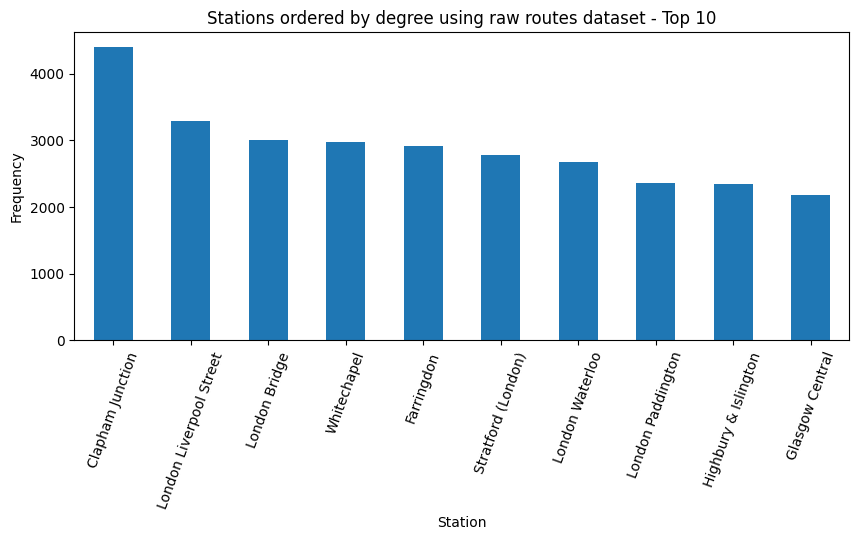

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
freq_df.head(10).plot(kind='bar', x='name', y='count', legend=False, figsize=(10,4))
plt.title("Stations ordered by degree using raw routes dataset - Top 10")
plt.xlabel("Station")
plt.ylabel("Frequency", loc='center')
plt.xticks(rotation=70)
plt.show()


In [18]:
import plotly.express as px 

fig = px.histogram(freq_df["count"], nbins=70, title="Number of routes that pass through a certain staion")

fig.show()


In [19]:
import plotly.express as px

fig = px.scatter_map(freq_df,
                    lat="lat",
                    lon="long",
                    size="count",
                    zoom=5,
                    hover_name="name"
    )

fig.update_layout(
    
    height=600,
    map_style="open-street-map",
    geo=dict(
        center=dict(
            lat=54.5057,
            lon=-1.7274
        ),
    )
)

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

## Population Analysis

In [20]:
uk_zip_code = pd.read_excel("../database/uk_la_future.xlsx",sheet_name="uk_local_authorities_future")
uk_zip_code.head()

,local-authority-code,official-name,nice-name,gss-code,start-date,end-date,replaced-by,nation,region,local-authority-type,...,lower-or-unitary,mapit-area-code,ofcom,old-ons-la-code,old-register-and-code,open-council-data-id,os-file,os,snac,wdtk-id
0,ABC,"Armagh City, Banbridge and Craigavon Borough C...","Armagh City, Banbridge and Craigavon",N09000002,2015-04-01,NaN,NaN,Northern Ireland,Northern Ireland,NID,...,True,NaN,95-OQN,NaN,local-authority-nir:ABC,1002.0,NaN,NaN,NaN,54906.0
1,ABD,Aberdeenshire Council,Aberdeenshire,S12000034,2005-06-18,NaN,NaN,Scotland,Scotland,SCO,...,True,NaN,00-QB,NaN,local-authority-sct:ABD,296.0,ABERDEENSHIRE,7.000000e+15,00QB,40.0
2,ABE,Aberdeen City Council,Aberdeen City,S12000033,2005-06-18,NaN,NaN,Scotland,Scotland,SCO,...,True,NaN,00-QA,NaN,local-authority-sct:ABE,295.0,ABERDEEN_CITY,7.000000e+15,00QA,39.0
3,ADU,Adur District Council,Adur,E07000223,NaN,NaN,NaN,England,South East,NMD,...,True,DIS,NaN,45UB,local-authority-eng:ADU,165.0,NaN,7.000000e+15,45UB,41.0
4,AGB,Argyll and Bute Council,Argyll and Bute,S12000035,2005-06-18,NaN,NaN,Scotland,Scotland,SCO,...,True,NaN,00-QD,NaN,local-authority-sct:AGB,298.0,ARGYLL_AND_BUTE,7.000000e+15,00QD,48.0


In [21]:
uk_zip_code.columns

Index(['local-authority-code', 'official-name', 'nice-name', 'gss-code',
       'start-date', 'end-date', 'replaced-by', 'nation', 'region',
       'local-authority-type', 'local-authority-type-name', 'county-la',
       'combined-authority', 'alt-names', 'former-gss-codes', 'notes',
       'current-authority', 'BS-6879', 'ecode', 'even-older-register-and-code',
       'gov-uk-slug', 'area', 'pop-2020', 'x', 'y', 'long', 'lat', 'powers',
       'lower-or-unitary', 'mapit-area-code', 'ofcom', 'old-ons-la-code',
       'old-register-and-code', 'open-council-data-id', 'os-file', 'os',
       'snac', 'wdtk-id'],
      dtype='object')

In [22]:
uk_population = pd.read_excel("../database/mye24tablesuk.xlsx",sheet_name="MYE2 - Persons", skiprows=7)
uk_population.head()

,Code,Name,Geography,All ages,0,1,2,3,4,5,...,81,82,83,84,85,86,87,88,89,90+
0,K02000001,UNITED KINGDOM,Country,69281437,667994,690113,732532,728400,755117,769993,...,414914,357410,305273,300816,281337,256103,224742,195365,167231,625236
1,K03000001,GREAT BRITAIN,Country,67353582,648105,669724,710426,706322,732313,746520,...,403452,347774,296936,293200,274184,249746,219033,190506,163096,610585
2,K04000001,ENGLAND AND WALES,Country,61806682,601329,622020,660624,656038,680640,692020,...,369527,318021,271613,268602,251783,229508,201631,175142,149932,563609
3,E92000001,ENGLAND,Country,58620101,573812,593575,630059,625948,648849,659421,...,347609,298656,255001,253116,237616,216590,190245,165268,141650,532643
4,E12000001,NORTH EAST,Region,2760678,25050,25791,27324,27213,27955,29149,...,16203,14435,12824,12644,11779,10802,9621,7940,7000,24491


In [23]:
uk_population = uk_population.loc[uk_population["Geography"]!="Country"]
uk_population.head()

,Code,Name,Geography,All ages,0,1,2,3,4,5,...,81,82,83,84,85,86,87,88,89,90+
4,E12000001,NORTH EAST,Region,2760678,25050,25791,27324,27213,27955,29149,...,16203,14435,12824,12644,11779,10802,9621,7940,7000,24491
5,E06000047,County Durham,Unitary Authority,538011,4708,4579,4876,4881,5141,5213,...,3411,2928,2706,2550,2330,2136,1971,1642,1376,4591
6,E06000005,Darlington,Unitary Authority,112489,1056,1042,1129,1134,1188,1196,...,678,605,574,568,528,460,404,340,318,1098
7,E06000001,Hartlepool,Unitary Authority,98180,947,988,1046,1045,1117,1154,...,458,477,414,434,388,389,332,239,262,849
8,E06000002,Middlesbrough,Unitary Authority,156161,1881,1900,1950,1850,1873,1946,...,685,680,568,530,503,489,399,367,324,1179


In [24]:
uk_population= uk_population.drop(uk_population.iloc[:,4:95],axis=1)
uk_population.head()

,Code,Name,Geography,All ages
4,E12000001,NORTH EAST,Region,2760678
5,E06000047,County Durham,Unitary Authority,538011
6,E06000005,Darlington,Unitary Authority,112489
7,E06000001,Hartlepool,Unitary Authority,98180
8,E06000002,Middlesbrough,Unitary Authority,156161


In [25]:
uk_population = uk_population.merge(uk_zip_code, left_on="Code", right_on="gss-code", how="left")
uk_population.head()

,Code,Name,Geography,All ages,local-authority-code,official-name,nice-name,gss-code,start-date,end-date,...,lower-or-unitary,mapit-area-code,ofcom,old-ons-la-code,old-register-and-code,open-council-data-id,os-file,os,snac,wdtk-id
0,E12000001,NORTH EAST,Region,2760678,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E06000047,County Durham,Unitary Authority,538011,DUR,Durham County Council,County Durham,E06000047,2009-04-01,NaN,...,True,UTA,00-EJ,840,local-authority-eng:DUR,338.0,COUNTY_DURHAM,7.000000e+15,00EJ,165.0
2,E06000005,Darlington,Unitary Authority,112489,DAL,Darlington Borough Council,Darlington,E06000005,1997-04-01,NaN,...,True,UTA,00-EH,841,local-authority-eng:DAL,337.0,DARLINGTON_(B),7.000000e+15,00EH,149.0
3,E06000001,Hartlepool,Unitary Authority,98180,HPL,Hartlepool Borough Council,Hartlepool,E06000001,2005-06-18,NaN,...,True,UTA,00-EB,805,local-authority-eng:HPL,369.0,HARTLEPOOL_(B),7.000000e+15,00EB,213.0
4,E06000002,Middlesbrough,Unitary Authority,156161,MDB,Middlesbrough Borough Council,Middlesbrough,E06000002,2005-06-18,NaN,...,True,UTA,00-EC,806,local-authority-eng:MDB,346.0,MIDDLESBROUGH_(B),7.000000e+15,00EC,264.0


In [26]:
uk_population.columns

Index(['Code', 'Name', 'Geography', 'All ages', 'local-authority-code',
       'official-name', 'nice-name', 'gss-code', 'start-date', 'end-date',
       'replaced-by', 'nation', 'region', 'local-authority-type',
       'local-authority-type-name', 'county-la', 'combined-authority',
       'alt-names', 'former-gss-codes', 'notes', 'current-authority',
       'BS-6879', 'ecode', 'even-older-register-and-code', 'gov-uk-slug',
       'area', 'pop-2020', 'x', 'y', 'long', 'lat', 'powers',
       'lower-or-unitary', 'mapit-area-code', 'ofcom', 'old-ons-la-code',
       'old-register-and-code', 'open-council-data-id', 'os-file', 'os',
       'snac', 'wdtk-id'],
      dtype='object')

In [27]:
uk_population = uk_population.loc[uk_population["x"]!= None]
uk_population = uk_population.loc[uk_population["y"]!= None]

In [28]:
uk_population.describe()

,All ages,area,pop-2020,x,y,long,lat,open-council-data-id,os,wdtk-id
count,3.970000e+02,379.000000,3.790000e+02,379.000000,3.790000e+02,379.000000,379.000000,373.000000,3.610000e+02,377.000000
mean,4.041811e+05,764.319261,2.469402e+05,431062.180239,3.061277e+05,52.639447,-1.573273,240.187668,7.000000e+15,2742.286472
std,1.033079e+06,1704.806532,5.006972e+05,115551.780933,1.766837e+05,1.586553,1.723603,176.335616,1.201598e+04,12719.867770
min,2.366000e+03,3.000000,2.226000e+03,43329.565502,1.302053e+04,49.936933,-7.503784,2.000000,7.000000e+15,3.000000
25%,1.142530e+05,95.000000,1.083250e+05,361484.915456,1.791781e+05,51.498099,-2.610750,123.000000,7.000000e+15,172.000000
50%,1.568750e+05,282.000000,1.482900e+05,445815.055886,2.654656e+05,52.255868,-1.327201,231.000000,7.000000e+15,278.000000
75%,2.926550e+05,715.000000,2.617385e+05,522415.726161,3.896712e+05,53.401612,-0.220773,324.000000,7.000000e+15,401.000000
max,9.642942e+06,25653.000000,9.002488e+06,647812.362211,1.168116e+06,60.394861,1.661393,1011.000000,7.000000e+15,91513.000000


In [29]:
import plotly.express as px

new_fig = px.scatter_map(uk_population,
                    lat="long",
                    lon="lat",
                    size="All ages",
                    hover_name="Name",
                    zoom=4
    )

new_fig.update_layout(
    height=600,
    map_style="open-street-map",
    geo=dict(
        center=dict(
            lat=54.5057,
            lon=-1.7274
        ),
    )
)

new_fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
new_fig.show()

# Hypergraph Analysis

In [30]:
import hypernetx.algorithms
hypergraph = hnx.Hypergraph(routes)
clean_routes_hypergraph = hnx.Hypergraph(clean_routes)
node_list = hypergraph.nodes
stations_degree = pd.DataFrame(columns=["station"])
stations_degree["station"] = node_list
stations_degree["not_clean_routes_degree"] = [hypergraph.degree(s) for s in stations_degree["station"]]
stations_degree["clean_routes_degree"] = [clean_routes_hypergraph.degree(s) for s in stations_degree["station"]]

stations_degree = stations_degree.merge(stations, left_on="station", right_on="code", how="left")


## Centrality Measures

In [ ]:
## betweeness Centraily
betweeness = hypernetx.s_betweenness_centrality(clean_routes_hypergraph, edges=False)

In [ ]:
print(betweeness)

{np.int64(0): 0.00010090127472832386, np.int64(1): 0.00010090127472832386, np.int64(2): 0.00010090127472832386, np.int64(3): 0.00010090127472832386, np.int64(4): 7.566093610736587e-07, np.int64(5): 4.904890366560025e-05, np.int64(6): 3.9258282153346114e-05, np.int64(7): 3.9258282153346114e-05, np.int64(8): 0.0001102174781099055, np.int64(9): 0.0, np.int64(10): 0.0, np.int64(11): 0.0, np.int64(12): 0.0, np.int64(13): 0.0, np.int64(14): 0.0, np.int64(15): 0.002142092958561112, np.int64(16): 0.0022618240112470107, np.int64(17): 0.0030599067576244326, np.int64(18): 0.0022618240112470107, np.int64(19): 2.9325054563574475e-05, np.int64(20): 2.9325054563574475e-05, np.int64(21): 0.00018304902475575413, np.int64(22): 0.00018304902475575413, np.int64(23): 0.004148136813124536, np.int64(24): 0.004148136813124536, np.int64(25): 0.0013348561439199935, np.int64(26): 0.0013348561439199935, np.int64(27): 1.2781464454043152e-05, np.int64(28): 1.2781464454043152e-05, np.int64(29): 0.0, np.int64(30): 0.

In [ ]:
nodes = clean_routes_hypergraph.nodes
meu_dict = []
for node in nodes:
    btw = hypernetx.s_closeness_centrality(clean_routes_hypergraph,source=node, edges=False)
    meu_dict.append([node, btw])

KeyboardInterrupt: 

In [ ]:
fig = px.histogram(stations_degree["degree"],labels=stations_degree["station"], nbins=70, title="Number of routes that pass through a certain staion")
fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter_map(stations_degree,
                    lat="lat",
                    lon="long",
                    size="not_clean_routes_degree",
                    zoom=5,
                    hover_name="name"
    )

fig.update_layout(
    
    height=600,
    map_style="open-street-map",
    geo=dict(
        center=dict(
            lat=54.5057,
            lon=-1.7274
        ),
    )
)

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()